# Time Series Analysis of Orders Shipped

In [2]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import polars as pl


training_csv_path = "C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/dat_train1 (1).csv"
output_path = "C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/timeseries_data_2.parquet"


In [ ]:
from collections import defaultdict

SUCCESS_ID = 28

def count_ed28_by_timestamp_chunked(input_csv_path, output_parquet_path):
    chunk_size = 1_000_000  # adjust as needed
    counts = defaultdict(int)

    reader = pl.read_csv(
        input_csv_path,
        batch_size=chunk_size
    )

    for batch in reader.iter_slices(n_rows=chunk_size):
        df = (
            batch
            .unique(subset=["id", "ed_id", "event_timestamp"])
            .with_columns(
                pl.col("event_timestamp")
                .str.to_datetime(time_zone="UTC", strict=False)
            )
            .filter(pl.col("ed_id") == SUCCESS_ID)
        )

        # aggregate within chunk
        grouped = df.group_by("event_timestamp").agg(pl.len())

        # accumulate globally
        for ts, cnt in zip(grouped["event_timestamp"], grouped["len"]):
            counts[ts] += cnt

        print(f"Processed chunk with {len(batch)} rows")

    # convert final result
    final_df = pl.DataFrame({
        "event_timestamp": list(counts.keys()),
        "count_ed_28": list(counts.values())
    }).sort("event_timestamp")

    final_df.write_parquet(output_parquet_path)


count_ed28_by_timestamp_chunked(training_csv_path, output_path)

Instead of collapsing the data to individual journeys when loading it in, we extract only the timestamps and the number of successes at each time into a new dataframe

In [3]:
path2 = Path("C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/timeseries_data_2.parquet")
time_series_2 = (
    pl.scan_parquet(path2).collect()
)
time_series_2 = time_series_2.to_pandas()
time_series_2 = time_series_2.sort_values('event_timestamp')
time_series_2['total_orders'] =time_series_2['count_ed_28'].cumsum()
time_series_2["month"] = (
    time_series_2['event_timestamp'].dt.year.astype(str)
     + '-M' +
    time_series_2["event_timestamp"].dt.month.astype(str))
time_series_2 = time_series_2.rename(columns = {
    'event_timestamp':'time',
    'count_ed_28': 'orders'
})
time_series_2

,time,orders,total_orders,month
0,2020-11-26 00:00:00+00:00,1,1,2020-M11
1,2020-12-10 00:00:00+00:00,1,2,2020-M12
2,2020-12-12 00:00:00+00:00,1,3,2020-M12
3,2020-12-15 00:00:00+00:00,1,4,2020-M12
4,2020-12-17 00:00:00+00:00,1,5,2020-M12
...,...,...,...,...
735,2023-01-19 00:00:00+00:00,186,278908,2023-M1
736,2023-01-20 00:00:00+00:00,84,278992,2023-M1
737,2023-01-21 00:00:00+00:00,19,279011,2023-M1
738,2023-01-22 00:00:00+00:00,11,279022,2023-M1


In [4]:
daily_orders = (
    time_series_2
    .groupby(['time'])['orders']
    .sum()
    .reset_index(name = 'daily_orders')
)
daily_orders.head()

,time,daily_orders
0,2020-11-26 00:00:00+00:00,1
1,2020-12-10 00:00:00+00:00,1
2,2020-12-12 00:00:00+00:00,1
3,2020-12-15 00:00:00+00:00,1
4,2020-12-17 00:00:00+00:00,1


## Time Series Analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

First we visualise the Time Series

Text(0, 0.5, 'Orders')

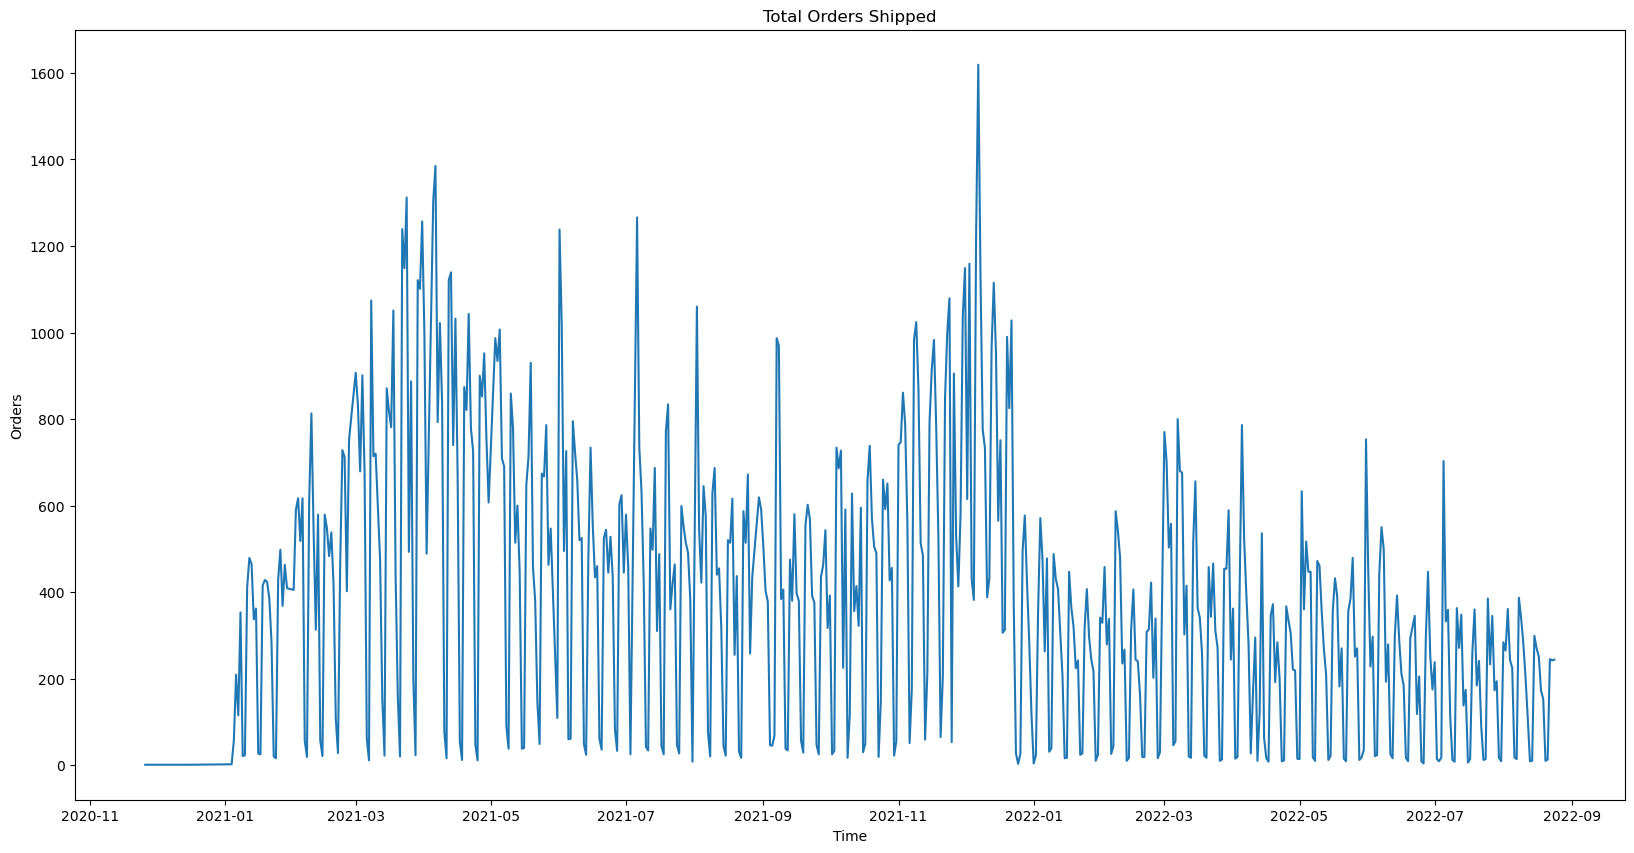

In [138]:
size = 587
test_size = 153
train = daily_orders[:size + 1]
test = daily_orders[size:]


plt.figure(figsize = (20,10))
plt.plot(train['time'],
         train['daily_orders'])
plt.title('Total Orders Shipped')
plt.xlabel('Time')
plt.ylabel('Orders')

Text(0, 0.5, 'Orders')

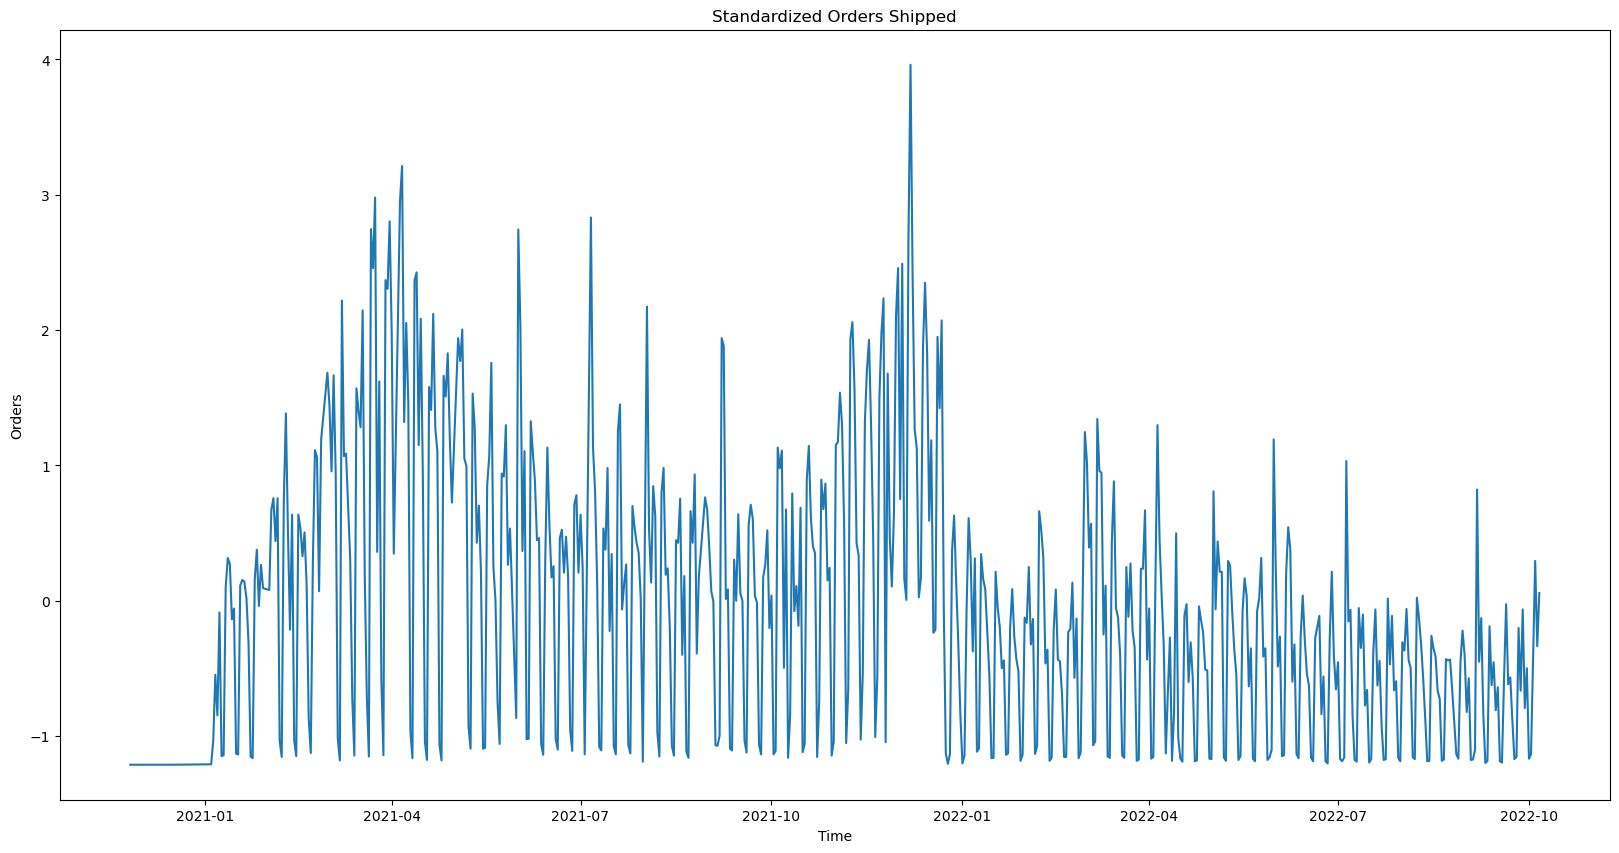

In [129]:
train['daily_orders_norm'] = (train['daily_orders'] - train['daily_orders'].mean())/(train['daily_orders'].std())
plt.figure(figsize = (20,10))
plt.plot(train['time'],
         train['daily_orders_norm'])
plt.title('Standardized Orders Shipped')
plt.xlabel('Time')
plt.ylabel('Orders')

## Plot ACF and PACF

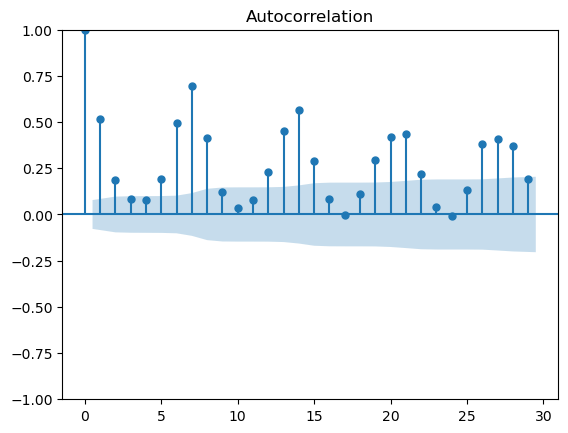

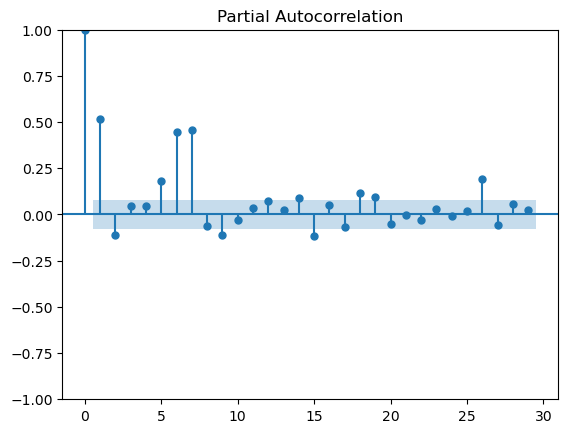

In [130]:
plot_acf(train['daily_orders'])
plot_pacf(train['daily_orders'])
plt.show()

The ACF of the original data plots oscilates quite regularly every 7 days, indicating a weeky seasonal component in the data.

We can remove this using moving averages. First we de-trend the data. There are 2 clear trends, increasing from the beginning to aproxximately 2021-04, the 4th week in 2021. Then there is a decreasing trend.


Text(0, 0.5, 'Orders Shipped')

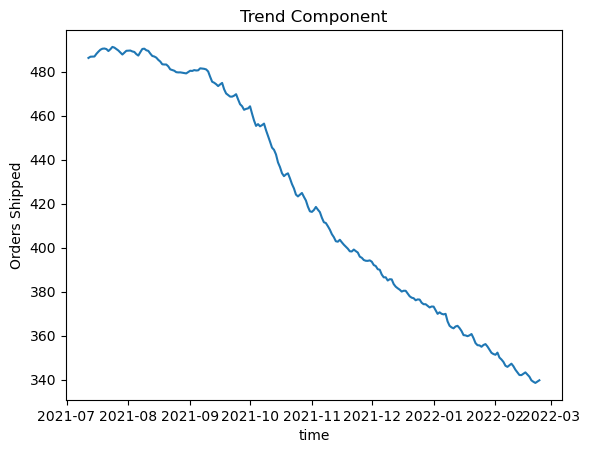

In [140]:
train['TC'] = train['daily_orders'].rolling(window=365, center=True).mean()
plt.plot(train['time'], train['TC'])
plt.title('Trend Component')
plt.xlabel('time')
plt.ylabel('Orders Shipped')

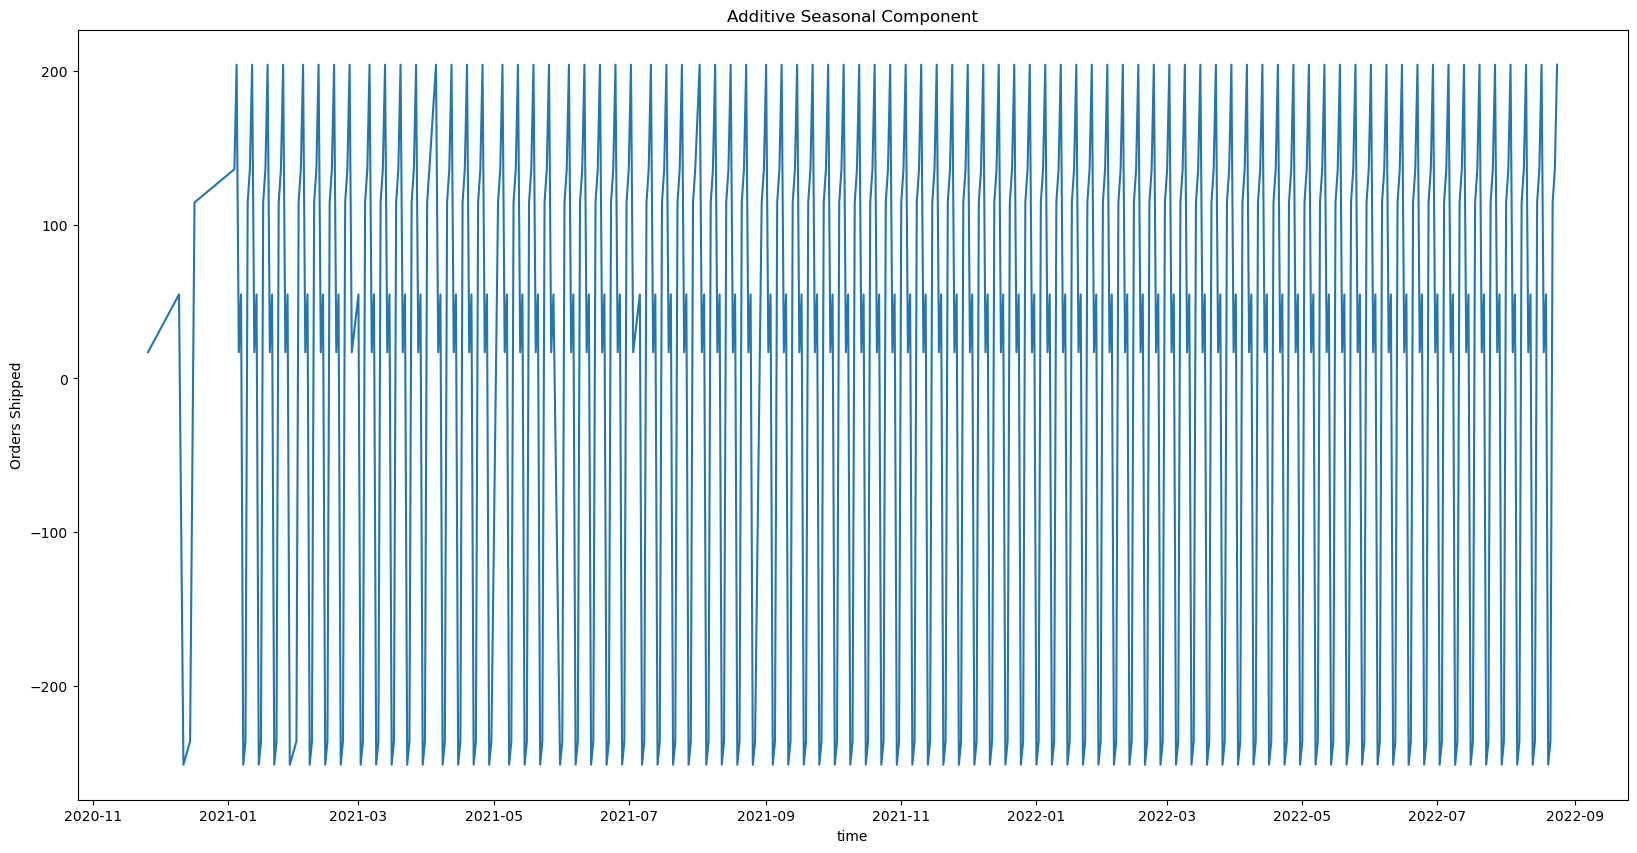

In [144]:
k = 7
k_monthly = 12
matrix_s_add = pd.DataFrame(
    np.array(train['daily_orders']-train['TC'])
    .reshape(k, -1, order='F'))
matrix_S_month = pd.DataFrame(
    np.array(train['daily_orders'] - train['TC'])
    .reshape(k_monthly, -1, order = 'F')
)
S_add = np.nanmean(matrix_s_add, axis = 1)
S_monthly = np.nanmean(matrix_S_month, axis = 1)
matrix_s_mult = pd.DataFrame(
    np.array(train['daily_orders']/train['TC'])
    . reshape(k, -1, order = 'F'))
S_mult = np.nanmean(matrix_s_mult, axis = 1)
S_mult = S_mult/S_mult.mean()

n_rep = int(len(train['daily_orders'])/7)
n_rep_month = int(len(train['daily_orders'])/12)

S_forecast = np.tile(S_add, 22)[:test_size]
S_forecast_month = np.tile(S_monthly, 13)[:test_size]
plt.figure(figsize = (20,10))
plt.plot(train['time'], np.tile(S_add, n_rep))
plt.title('Additive Seasonal Component')
plt.xlabel('time')
plt.ylabel('Orders Shipped')


plt.show()

Text(0, 0.5, 'Orders Shipped')

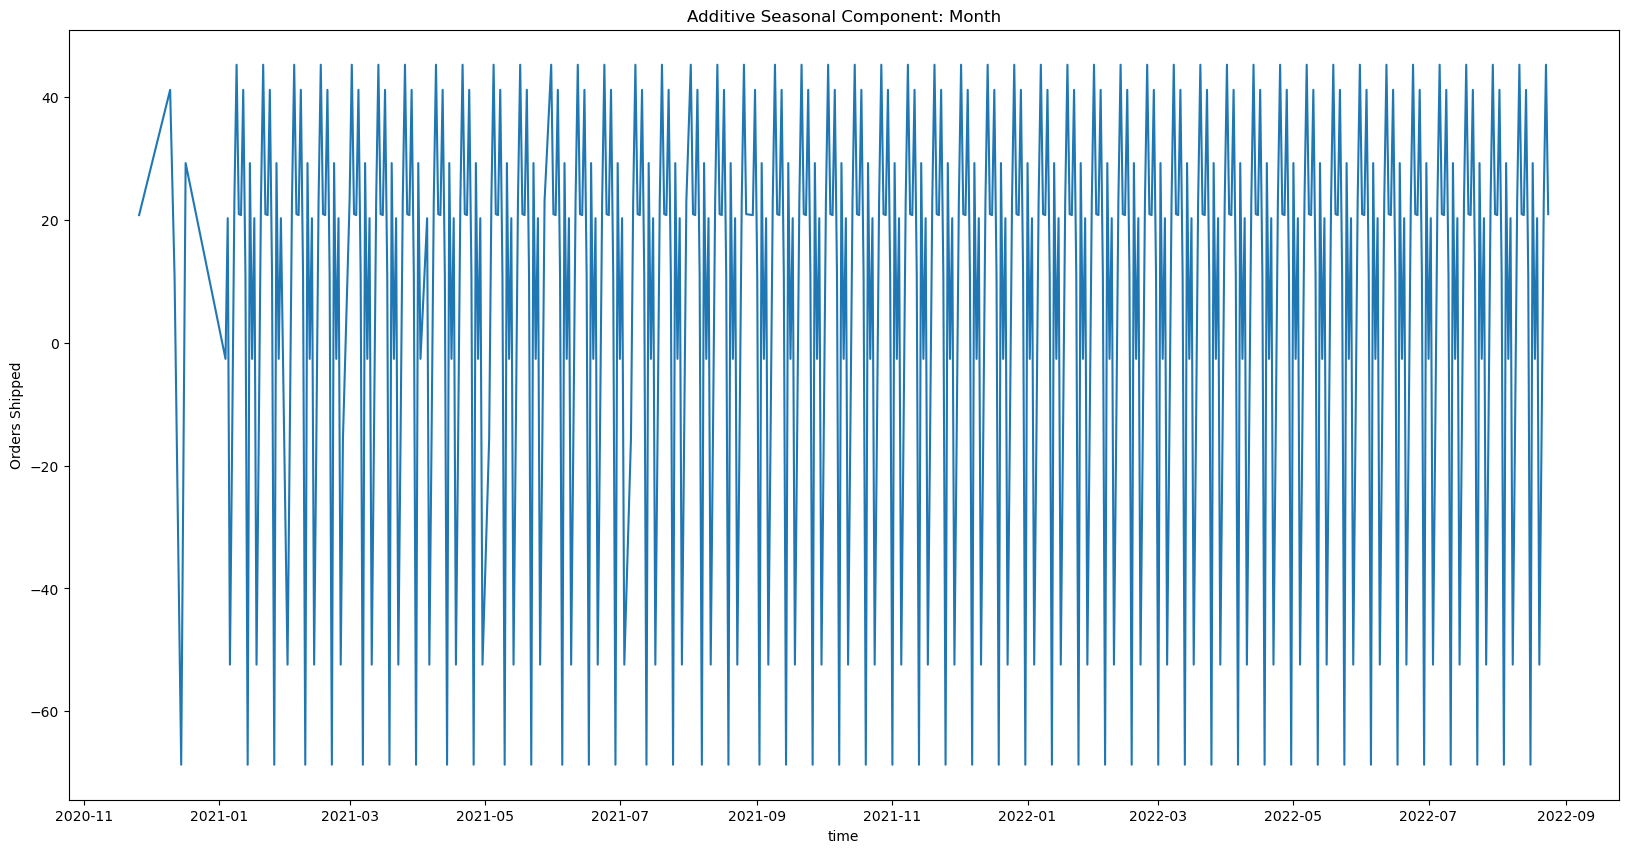

In [145]:
plt.figure(figsize = (20,10))
plt.plot(train['time'], np.tile(S_monthly, n_rep_month))
plt.title('Additive Seasonal Component: Month')
plt.xlabel('time')
plt.ylabel('Orders Shipped')

Text(0, 0.5, 'Orders Shipped')

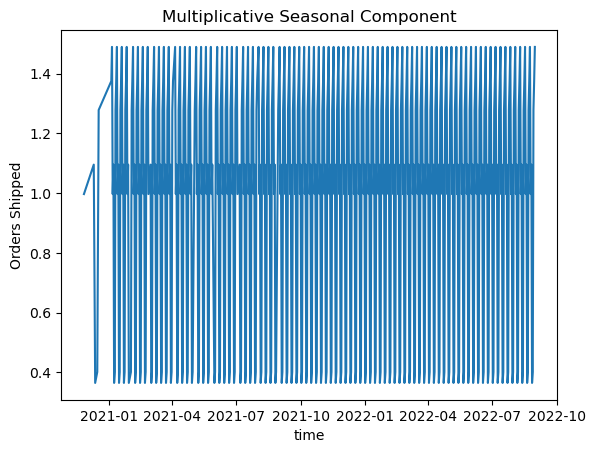

In [78]:
plt.plot(train['time'],np.tile(S_mult, n_rep))
plt.xlabel('time')
plt.title('Multiplicative Seasonal Component')
plt.ylabel('Orders Shipped')

We can remove the seasonal component using an additive model or a multiplicatve model

In [146]:

O_add = (train['daily_orders'] - np.tile(S_add, n_rep) - np.tile(S_monthly, n_rep_month) - train['TC'])
O_mult = (train['daily_orders']/(np.tile(S_mult, n_rep)*train['TC']))


Text(0.5, 1.0, 'Seasonally Adjusted: Additive')

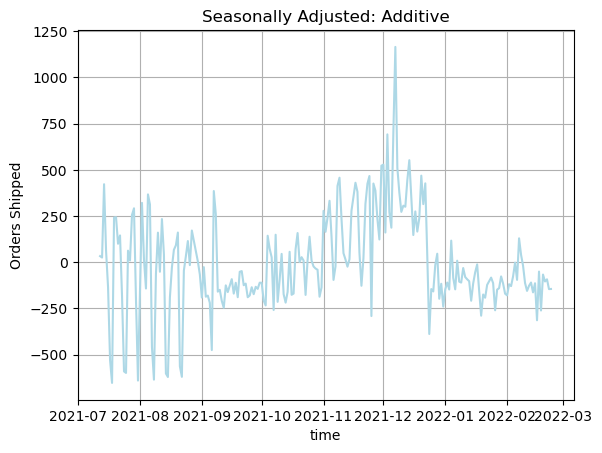

In [ ]:
plt.plot(train['time'],
        O_add, 
         color = 'lightblue')
plt.grid('lightgrey')
plt.xlabel('time')
plt.ylabel('Orders Shipped')
plt.title('Trend and Seasonally Adjusted: Additive')

Now there is clear heteroskedasticity in the data, it is much more volatile at the beginning and the variance decreases as time moves forward. There are also clear periods og high volatility and periods of lower volatility.

Other than that, the random component of the data appears to be white noise.

Text(0.5, 1.0, 'Seasonally Adjusted: Multiplicative')

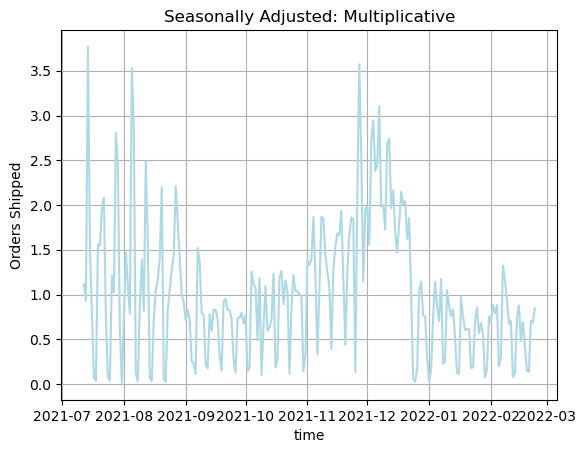

In [148]:
plt.plot(train['time'],
        O_mult, 
         color = 'lightblue')
plt.grid('lightgrey')
plt.xlabel('time')
plt.ylabel('Orders Shipped')
plt.title('Seasonally Adjusted: Multiplicative')


The ACF for both randm components is null, further indicating that they are white noise

In [93]:

from statsmodels.tsa.stattools import adfuller
adfuller(O_add.dropna())

(np.float64(-1.750543747812485),
 np.float64(0.4052767676298281),
 12,
 218,
 {'1%': np.float64(-3.460707667106296),
  '5%': np.float64(-2.874891213486339),
  '10%': np.float64(-2.573885987711472)},
 np.float64(2847.1126516965833))

The p-value of the Augmented Dickey Fuller test is 0.25 > 0.05, which means that there is evidence at the 5% significance level that this time series is integrated and therefore needs to be differenced.

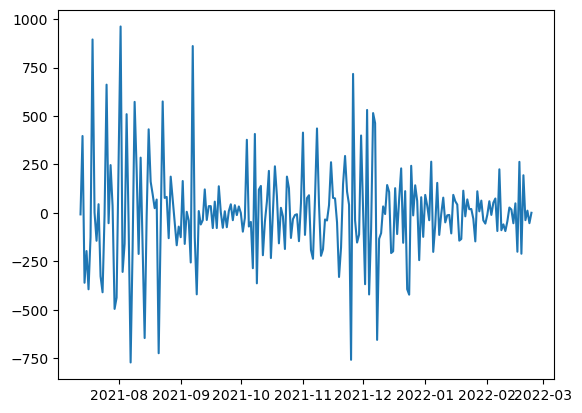

In [149]:
O_add_diff= O_add.diff()
plt.plot(train['time'], O_add_diff)
plt.show()


In [156]:
from arch import arch_model
garch = arch_model(O_add.dropna(), vol = 'Garch',
                   p = 1, q = 1)
garch_fit = garch.fit()
garch_fore = garch_fit.forecast(horizon = len(test['daily_orders']))
var = garch_fore.variance.values[-1]
sd = np.sqrt(var)
print(len(sd), len(test['daily_orders']))

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1827.5623445870744
Iteration:      2,   Func. Count:     13,   Neg. LLF: 1530.182232697609
Iteration:      3,   Func. Count:     18,   Neg. LLF: 1648.0939506983168
Iteration:      4,   Func. Count:     24,   Neg. LLF: 1529.4321338405186
Iteration:      5,   Func. Count:     30,   Neg. LLF: 1507.2412091766369
Iteration:      6,   Func. Count:     35,   Neg. LLF: 1507.1557980411997
Iteration:      7,   Func. Count:     40,   Neg. LLF: 1507.1466733631764
Iteration:      8,   Func. Count:     45,   Neg. LLF: 1507.146597313638
Iteration:      9,   Func. Count:     49,   Neg. LLF: 1507.1465973138768
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1507.146597313638
            Iterations: 9
            Function evaluations: 49
            Gradient evaluations: 9
153 153


c:\Users\cscur\miniconda3\envs\myenv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.832e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [157]:
n = len(test['daily_orders'])
rng = np.random.default_rng()
R = rng.normal(0, sd, n)

Text(0, 0.5, 'Orders')

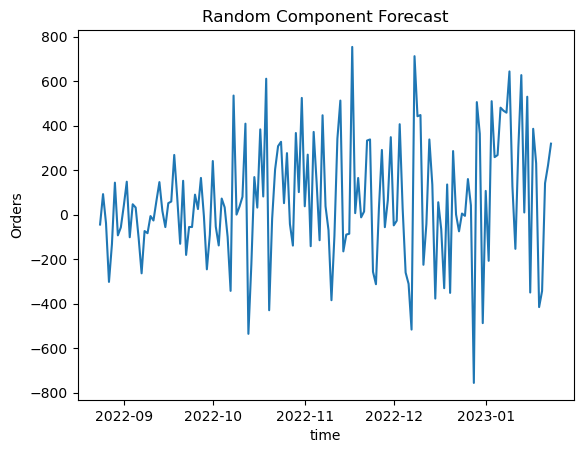

In [158]:
plt.plot(test['time'], R)
plt.title('Random Component Forecast')
plt.xlabel('time')
plt.ylabel('Orders')

In [159]:
# drop NaNs from rolling
tc = train['TC'].dropna().values
t = np.arange(len(tc))

# fit linear model
coef = np.polyfit(t, tc, 1)

# forecast 146 steps ahead
t_future = np.arange(len(tc), len(tc) + n)
TC_forecast = np.polyval(coef, t_future)


In [161]:
orders_forecast = S_forecast + S_forecast_month + TC_forecast + R
orders_forecast = np.maximum(orders_forecast, 0)

## Forecasting

In [13]:
steps = len(test['daily_orders'])
forecast = ar_1_fit.forecast(steps = steps)

mse = mean_squared_error(test['daily_orders'], forecast)
mse

86409.4269960403

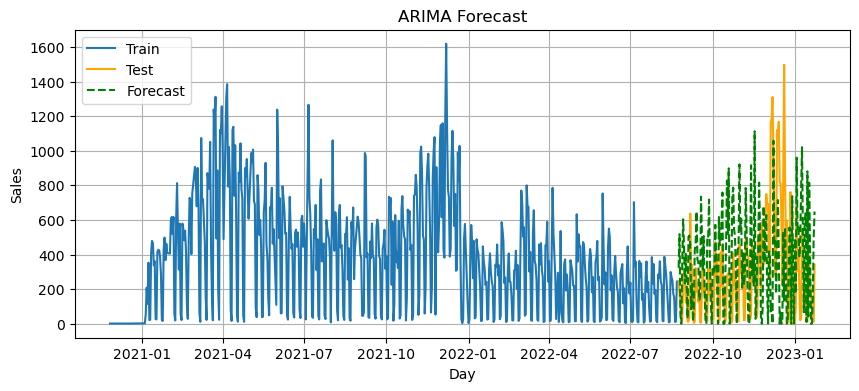

In [163]:
plt.figure(figsize=(10, 4))
plt.plot(train['time'], train['daily_orders'], label="Train")
plt.plot(test['time'], test['daily_orders'], label="Test", color="orange")
plt.plot(test['time'], orders_forecast, label="Forecast", color="green", linestyle="--")
plt.title("ARIMA Forecast")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


Checking the residuals of the model

# Forecasting 2023

Text(0, 0.5, 'Orders Shipped')

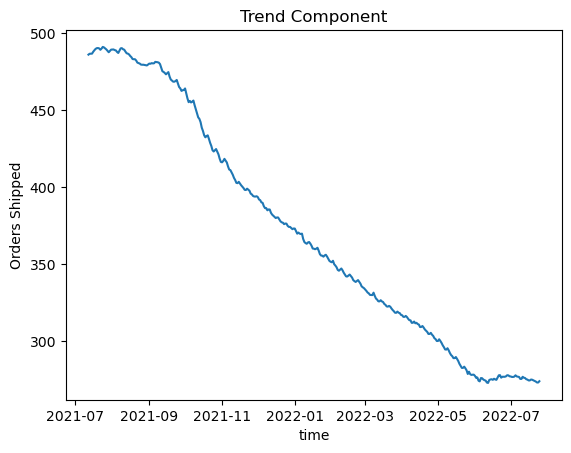

In [6]:
daily_orders['TC'] = daily_orders['daily_orders'].rolling(window=365, center=True).mean()
plt.plot(daily_orders['time'], daily_orders['TC'])
plt.title('Trend Component')
plt.xlabel('time')
plt.ylabel('Orders Shipped')

Text(0, 0.5, 'Orders Shipped')

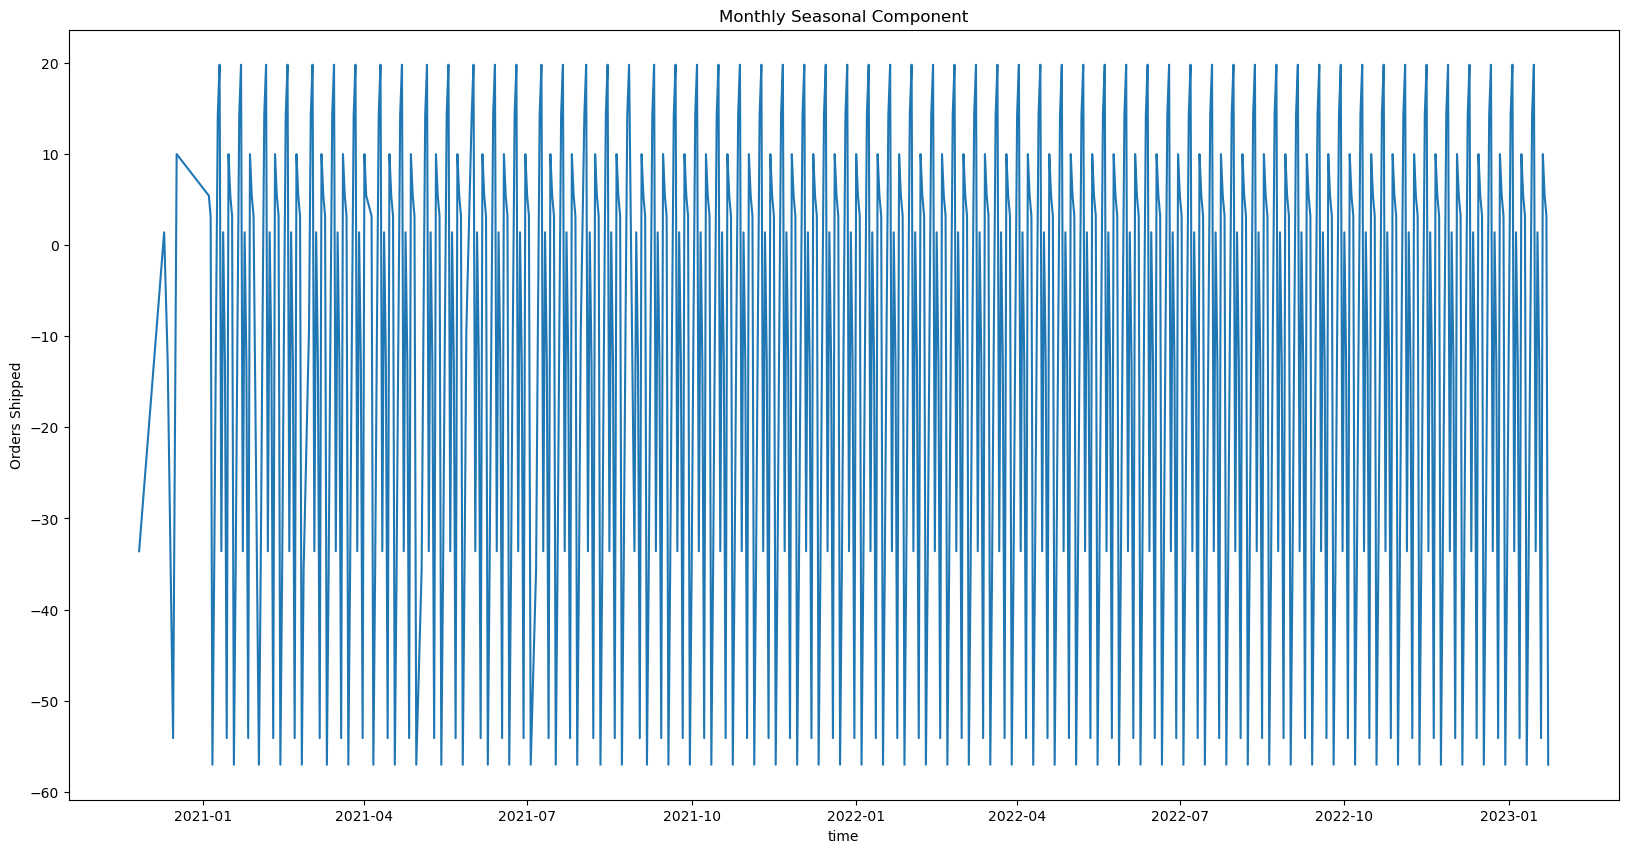

In [30]:
k = 7
k_monthly = 12
matrix_s = pd.DataFrame(
    np.array(daily_orders['daily_orders'][:735]-daily_orders['TC'][:735])
    .reshape(k, -1, order='F'))
matrix_S_month = pd.DataFrame(
    np.array(daily_orders['daily_orders'][:732] - daily_orders['TC'][:732])
    .reshape(k_monthly, -1, order = 'F')
)
S = np.nanmean(matrix_s, axis = 1)
S_monthly = np.nanmean(matrix_S_month, axis = 1)


n_rep = int(np.ceil(740/7))
n_rep_month = int(np.ceil(740/12))

S_forecast = np.tile(S, 50)[:365-23]
S_forecast_month = np.tile(S_monthly, 30)[:365-23]
plt.figure(figsize = (20,10))
plt.plot(daily_orders['time'], np.tile(S_monthly, n_rep_month)[:740])
plt.title('Monthly Seasonal Component')
plt.xlabel('time')
plt.ylabel('Orders Shipped')


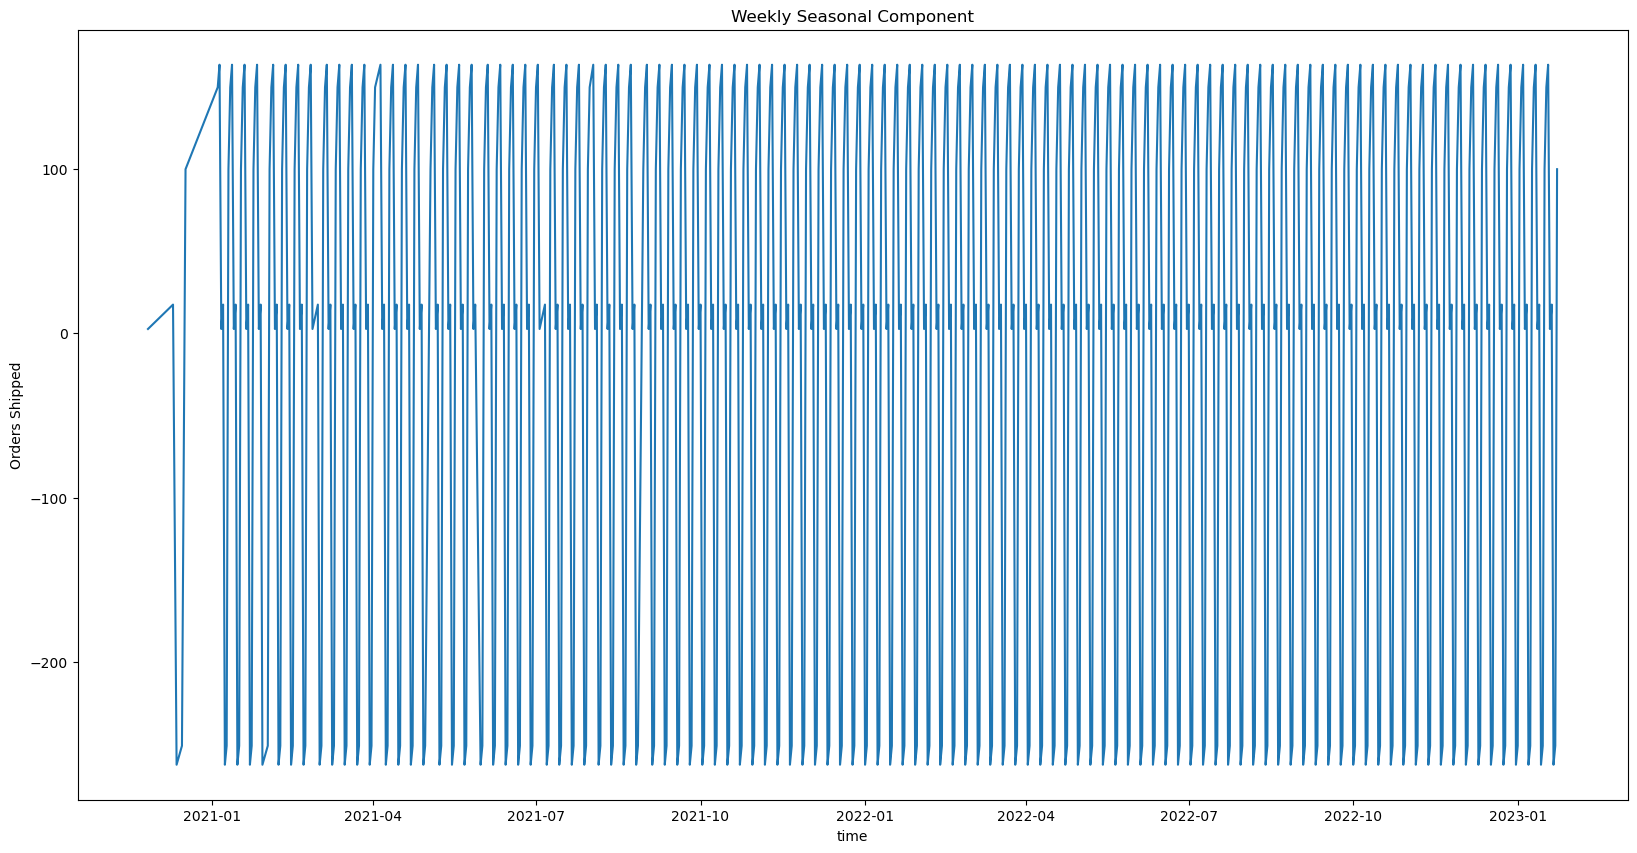

In [32]:
plt.figure(figsize = (20,10))
plt.plot(daily_orders['time'], np.tile(S, n_rep)[:740])
plt.title('Weekly Seasonal Component')
plt.xlabel('time')
plt.ylabel('Orders Shipped')

plt.show()

Text(0.5, 1.0, 'Trend and Seasonally Adjusted: Full')

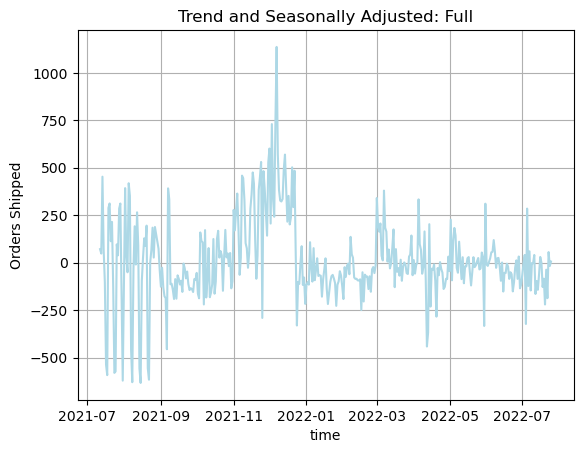

In [17]:
O_full = (daily_orders['daily_orders'] - np.tile(S, n_rep)[:740] - np.tile(S_monthly, n_rep_month)[:740] - daily_orders['TC'])
plt.plot(daily_orders['time'],
        O_full, 
         color = 'lightblue')
plt.grid('lightgrey')
plt.xlabel('time')
plt.ylabel('Orders Shipped')
plt.title('Trend and Seasonally Adjusted: Full')


In [20]:
from arch import arch_model
garch_full = arch_model(O_full.dropna(), vol = 'Garch',
                   p = 1, q = 1)
garch_full_fit = garch_full.fit()
garch_full_fore = garch_full_fit.forecast(horizon = (365-23))
var_full = garch_full_fore.variance.values[-1]
sd_full = np.sqrt(var_full)


Iteration:      1,   Func. Count:      6,   Neg. LLF: 2739.7354524271013
Iteration:      2,   Func. Count:     12,   Neg. LLF: 3000.605919554615
Iteration:      3,   Func. Count:     18,   Neg. LLF: 3184.676515112729
Iteration:      4,   Func. Count:     24,   Neg. LLF: 2457.094833884138
Iteration:      5,   Func. Count:     29,   Neg. LLF: 2457.025601148859
Iteration:      6,   Func. Count:     34,   Neg. LLF: 2456.986238884434
Iteration:      7,   Func. Count:     39,   Neg. LLF: 2456.9857040856546
Iteration:      8,   Func. Count:     44,   Neg. LLF: 2456.9856165465544
Iteration:      9,   Func. Count:     49,   Neg. LLF: 2456.9852749164656
Iteration:     10,   Func. Count:     54,   Neg. LLF: 2456.984549224423
Iteration:     11,   Func. Count:     59,   Neg. LLF: 2456.9823681355874
Iteration:     12,   Func. Count:     64,   Neg. LLF: 2456.9769243764968
Iteration:     13,   Func. Count:     69,   Neg. LLF: 2456.9625416110207
Iteration:     14,   Func. Count:     74,   Neg. LLF: 245

c:\Users\cscur\miniconda3\envs\myenv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.748e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [21]:
# drop NaNs from rolling
tc = daily_orders['TC'].dropna().values
t = np.arange(len(tc))

# fit linear model
coef = np.polyfit(t, tc, 1)

# forecast 146 steps ahead
n = 365-23
t_future = np.arange(len(tc), len(tc) + n)
TC_forecast = np.polyval(coef, t_future)


rng = np.random.default_rng()
R = rng.normal(0, sd_full, n)

In [25]:
orders_forecast = S_forecast + S_forecast_month + TC_forecast + R
orders_forecast = np.maximum(orders_forecast, 0)

# last date in your training data
start_date = pd.to_datetime("2023-01-24")

# end of year
end_date = pd.to_datetime("2023-12-31")

# create future time index
future_time = pd.date_range(start=start_date, end=end_date, freq='D')

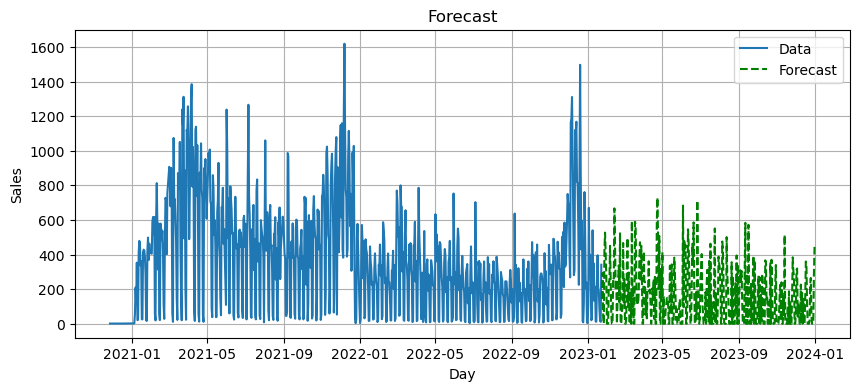

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(daily_orders['time'], daily_orders['daily_orders'], label="Data")
plt.plot(future_time, orders_forecast, label="Forecast", color="green", linestyle="--")
plt.title("Forecast")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()